### MLM head diagram

RoBERTa-large's masked-language-model head: the corrupted sentence goes through
24 encoder layers, the masked position's final vector is read off, a dense +
GELU + LayerNorm block reshapes it, and a projection tied to the input embedding
table scores all $|V|$ vocabulary items.

Writes `mlm_head_diagram.png` and `.pdf`.


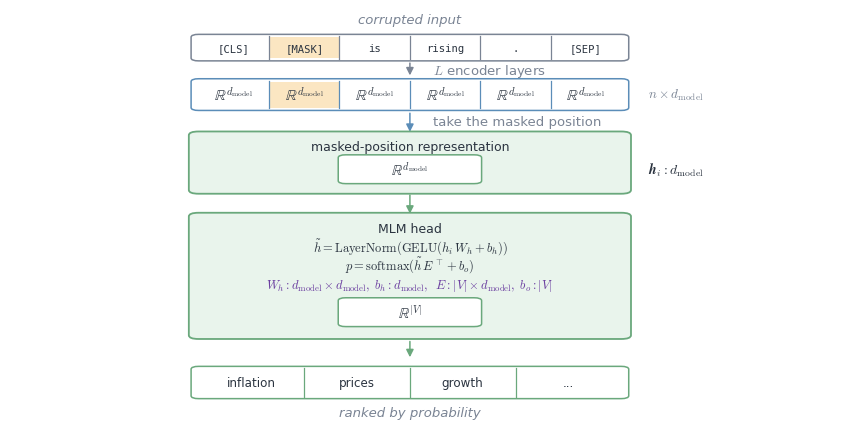

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "cm"
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK = "#2b3440"
BLUE_E = "#5b8db8"
GREEN, GREEN_E = "#e9f4ec", "#6aa87c"
GREYT = "#7a8494"
TRAIN = "#6b3fa0"
HILITE = "#fbe6c2"

fig, ax = plt.subplots(figsize=(8.6, 4.45))
ax.set_xlim(0, 11.0)
ax.set_ylim(-5.6, 8.8)
ax.axis("off")

X, W = 2.5, 5.6
MID = X + W / 2
NX = X + W + 0.35

MATHR = r"$\mathbb{R}^{d_{\mathrm{model}}}$"
MATHV = r"$\mathbb{R}^{|V|}$"
HLBL = r"$\boldsymbol{h}_i: d_{\mathrm{model}}$"
EQ1 = r"$\tilde{h} = \mathrm{LayerNorm}(\mathrm{GELU}(h_i\,W_h + b_h))$"
EQ2 = r"$p = \mathrm{softmax}(\tilde{h}\,E^{\top} + b_o)$"
PARAMS = (
    r"$W_h: d_{\mathrm{model}} \times d_{\mathrm{model}},\; b_h: d_{\mathrm{model}},\;\;"
    r"E: |V| \times d_{\mathrm{model}},\; b_o: |V|$"
)


def box(x, y, w, h, text, fc, ec, fs=9, lw=1.3):
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.13",
            facecolor=fc,
            edgecolor=ec,
            linewidth=lw,
        )
    )
    if text:
        ax.text(
            x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=INK
        )


def dim(x, y, text, ha="left"):
    ax.text(x, y, text, ha=ha, va="center", fontsize=9.5, style="italic", color=GREYT)


def note(y, text, fs=9.5, x=None):
    ax.text(
        MID + 0.3 if x is None else x,
        y,
        text,
        fontsize=fs,
        color=GREYT,
        ha="left",
        va="center",
    )


def arrow(y0, c=INK, x=None, dy=0.84):
    if x is None:
        x = MID
    ax.add_patch(
        FancyArrowPatch(
            (x, y0), (x, y0 - dy), arrowstyle="-|>", mutation_scale=11, color=c, lw=1.1
        )
    )


def table_row(
    y, labels, fs=8.2, fc="white", ec=GREYT, h=0.9, x=None, w=None, hi=None, mono=True
):
    if x is None:
        x = X
    if w is None:
        w = W
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.10",
            facecolor=fc,
            edgecolor=ec,
            linewidth=1.1,
            zorder=1,
        )
    )
    n = len(labels)
    if hi is not None:
        ax.add_patch(
            plt.Rectangle(
                (x + hi * w / n, y),
                w / n,
                h,
                facecolor=HILITE,
                edgecolor="none",
                zorder=1.5,
            )
        )
    for i, t in enumerate(labels):
        if i:
            ax.plot(
                [x + i * w / n, x + i * w / n],
                [y - 0.03, y + h + 0.03],
                color=ec,
                lw=0.9,
                zorder=2,
            )
        ax.text(
            x + (i + 0.5) * w / n,
            y + h / 2,
            t,
            ha="center",
            va="center",
            fontsize=fs,
            family="DejaVu Sans Mono" if mono else None,
            color=INK,
            zorder=3,
        )


# ---- corrupted input, masked position shaded -------------------------------
table_row(7.10, ["[CLS]", "[MASK]", "is", "rising", ".", "[SEP]"], fs=7.6, h=0.72, hi=1)
dim(MID, 8.45, "corrupted input", ha="center")
arrow(7.02, GREYT, dy=0.62)
note(6.68, r"$L$ encoder layers")

# ---- encoder output, same position shaded ----------------------------------
table_row(5.38, [MATHR] * 6, fs=11.0, ec=BLUE_E, h=0.9, hi=1)
dim(NX, 5.83, r"$n \times d_{\mathrm{model}}$")
arrow(5.28, BLUE_E)
note(4.90, "take the masked position")

# ---- masked-position representation ----------------------------------------
box(X, 2.52, W, 1.9, "", GREEN, GREEN_E)
ax.text(
    MID,
    4.04,
    "masked-position representation",
    ha="center",
    va="center",
    fontsize=9,
    color=INK,
)
table_row(2.84, [MATHR], fs=10.5, ec=GREEN_E, h=0.8, x=MID - 0.85, w=1.7, mono=False)
ax.text(NX, 3.24, HLBL, ha="left", va="center", fontsize=10, color=INK)
arrow(2.44, GREEN_E)

# ---- MLM head ---------------------------------------------------------------
box(X, -2.52, W, 4.12, "", GREEN, GREEN_E)
ax.text(MID, 1.18, "MLM head", ha="center", va="center", fontsize=9, color=INK)
ax.text(MID, 0.56, EQ1, ha="center", va="center", fontsize=9, color=INK)
ax.text(MID, -0.06, EQ2, ha="center", va="center", fontsize=9, color=INK)
ax.text(MID, -0.76, PARAMS, ha="center", va="center", fontsize=9.0, color=TRAIN)
table_row(-2.12, [MATHV], fs=10.5, ec=GREEN_E, h=0.8, x=MID - 0.85, w=1.7, mono=False)
arrow(-2.64, GREEN_E, dy=0.74)

# ---- output distribution ----------------------------------------------------
table_row(
    -4.62,
    ["inflation", "prices", "growth", "..."],
    fs=8.6,
    ec=GREEN_E,
    h=0.92,
    mono=False,
)
dim(MID, -5.20, "ranked by probability", ha="center")

fig.tight_layout()
fig.savefig("mlm_head_diagram.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig("mlm_head_diagram.pdf", bbox_inches="tight", facecolor="white")